In [5]:
import subprocess, sys

# ============================================================
#  环境配置
#  - Colab 用户：取消注释下方 Colab 区块
#  - 本地 Jupyter 用户：直接运行 Local 区块
# ============================================================

# ── Colab 环境（取消注释后运行） ──
# 卸载所有可能的 numpy 版本，确保环境干净
!pip uninstall -y numpy

# 安装 PyTorch 和 torchvision
!pip install "numpy~=1.26.4" "pandas<2.4.0" "matplotlib" "torch" "torchvision" -q --no-warn-conflicts

# ── 本地 Jupyter 环境 ──
def _install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

# 以下代码块无需手动运行，因为Colab环境已经通过上面的pip命令安装了依赖。
# _install("torch==2.5.1")
# _install("torchvision==0.20.1")
# _install("matplotlib==3.9.4")
# _install("numpy==1.26.4")

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4


# GAN 生成对抗网络 从零到一：源代码实现 vs 简洁实现

基于论文 *Generative Adversarial Nets* (Goodfellow et al., 2014)，
用 **MNIST 手写数字生成** 任务演示 GAN 的核心架构。

本 Notebook 包含两种实现，使用 **相同的超参数和数据**：

| | 实现 A — 源代码实现 | 实现 B — 简洁实现 |
|---|---|---|
| 核心思路 | 逐组件手写 Generator/Discriminator，含公式推导 | 使用 `nn.Sequential` 快速构建 |
| 代码量 | ~60 行 | ~30 行 |
| 适合场景 | 深入理解对抗训练原理、面试准备 | 快速原型、工程落地 |
| 推理方式 | 噪声 z → Generator → 生成图像 | 同左 |

In [6]:
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 1. 数据准备

使用 MNIST 手写数字数据集的子集（5000 张），像素归一化到 $[-1, 1]$ 以匹配生成器 Tanh 输出范围。

In [7]:
# ── 超参数（两种实现共用，集中管理） ──
LATENT_DIM   = 64       # 噪声向量维度 z ~ N(0,1)
HIDDEN_DIM   = 256      # 隐藏层维度（论文更大，此处缩小适配 CPU）
IMG_DIM      = 28 * 28  # MNIST 图像展平尺寸 (784)
LR           = 2e-4     # 学习率（DCGAN 推荐值）
BETA1        = 0.5      # Adam beta1（降低动量防止训练震荡）
BATCH_SIZE   = 64
NUM_EPOCHS   = 50       # CPU 友好
NUM_SAMPLES  = 5000     # MNIST 子集大小
K_STEPS      = 1        # 每轮判别器更新步数（论文 k=1）

In [8]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # [0,1] -> [-1,1]
])

full_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
dataset = Subset(full_dataset, range(NUM_SAMPLES))
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
print(f'数据集大小: {len(dataset)}, 批次数: {len(dataloader)}')

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 499kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.62MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.5MB/s]

数据集大小: 5000, 批次数: 78


批次形状: torch.Size([64, 1, 28, 28])
像素范围: [-1.0, 1.0]


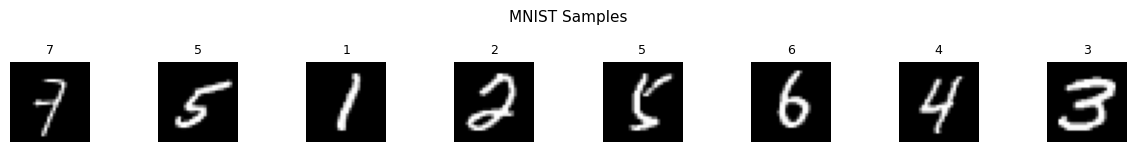

In [9]:
sample_batch, sample_labels = next(iter(dataloader))
print(f'批次形状: {sample_batch.shape}')    # (64, 1, 28, 28)
print(f'像素范围: [{sample_batch.min():.1f}, {sample_batch.max():.1f}]')

fig, axes = plt.subplots(1, 8, figsize=(12, 1.5))
for i, ax in enumerate(axes):
    ax.imshow(sample_batch[i, 0] * 0.5 + 0.5, cmap='gray')  # 反归一化
    ax.set_title(str(sample_labels[i].item()), fontsize=9)
    ax.axis('off')
plt.suptitle('MNIST Samples', fontsize=11)
plt.tight_layout()
plt.show()

## 2. 共享组件

权重初始化、可视化工具函数，以及两种实现共用的训练循环。

In [10]:
def weights_init(m):
    """Xavier 均匀初始化"""
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)


def show_generated(generator, latent_dim, n=16, title='Generated'):
    """生成并展示 n 张图片"""
    was_training = generator.training
    generator.eval()
    with torch.no_grad():
        z = torch.randn(n, latent_dim, device=device)
        imgs = generator(z).view(-1, 1, 28, 28).cpu()
    generator.train(was_training)  # 恢复原始模式

    imgs = imgs * 0.5 + 0.5  # [-1,1] -> [0,1]
    grid_size = int(np.ceil(np.sqrt(n)))
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(6, 6))
    for i, ax in enumerate(axes.flat):
        if i < n:
            ax.imshow(imgs[i, 0], cmap='gray')
        ax.axis('off')
    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()


def plot_losses(g_losses, d_losses, title='Loss Curves'):
    """绘制损失曲线"""
    plt.figure(figsize=(8, 4))
    plt.plot(g_losses, label='Generator Loss')
    plt.plot(d_losses, label='Discriminator Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### 训练循环

GAN 的训练在判别器和生成器之间**交替进行**（论文 Algorithm 1）：

1. **训练判别器** $k$ 步：沿**梯度上升**方向最大化价值函数
$$\nabla_{\theta_d} \frac{1}{m} \sum_{i=1}^{m} \left[\log D(x^{(i)}) + \log(1 - D(G(z^{(i)})))\right]$$

2. **训练生成器** 1 步：沿**梯度下降**方向最小化
$$\nabla_{\theta_g} \frac{1}{m} \sum_{i=1}^{m} \log(1 - D(G(z^{(i)})))$$

> **实践技巧**: 直接最小化 $\log(1 - D(G(z)))$ 在训练初期梯度太小（$D$ 轻易区分真假时梯度饱和）。替换为最大化 $\log D(G(z))$（即 `BCELoss(D(G(z)), 1)`），在训练初期提供更大梯度。

In [11]:
def train_gan(generator, discriminator, dataloader, num_epochs=NUM_EPOCHS,
              lr=LR, beta1=BETA1, latent_dim=LATENT_DIM, k_steps=K_STEPS):
    """
    GAN 训练循环（两种实现共用）
    交替训练 D 和 G，返回每个 epoch 的平均损失。
    """
    criterion = nn.BCELoss()
    opt_g = torch.optim.Adam(generator.parameters(), lr=lr, betas=(beta1, 0.999))
    opt_d = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(beta1, 0.999))

    g_losses, d_losses = [], []

    for epoch in range(num_epochs):
        epoch_g, epoch_d, n_batch = 0.0, 0.0, 0

        for real_imgs, _ in dataloader:
            bs = real_imgs.size(0)
            real_imgs = real_imgs.view(bs, -1).to(device)  # (batch, 784)

            ones  = torch.ones(bs, 1, device=device)
            zeros = torch.zeros(bs, 1, device=device)

            # ── 步骤 1: 训练判别器 (k 步) ──
            for _ in range(k_steps):
                z = torch.randn(bs, latent_dim, device=device)  # (batch, latent_dim)
                fake_imgs = generator(z).detach()                # (batch, 784), detach 阻断 G 梯度

                d_real = discriminator(real_imgs)                 # (batch, 1)
                d_fake = discriminator(fake_imgs)                 # (batch, 1)

                # max E[log D(x)] + E[log(1 - D(G(z)))]
                d_loss = (criterion(d_real, ones) + criterion(d_fake, zeros)) / 2

                opt_d.zero_grad()
                d_loss.backward()
                opt_d.step()

            # ── 步骤 2: 训练生成器 (1 步) ──
            z = torch.randn(bs, latent_dim, device=device)
            fake_imgs = generator(z)                             # (batch, 784)
            d_fake = discriminator(fake_imgs)                    # (batch, 1)

            # 非饱和损失: max log D(G(z)) ≡ min BCELoss(D(G(z)), 1)
            g_loss = criterion(d_fake, ones)

            opt_g.zero_grad()
            g_loss.backward()
            opt_g.step()

            epoch_g += g_loss.item()
            epoch_d += d_loss.item()
            n_batch += 1

        avg_g = epoch_g / n_batch
        avg_d = epoch_d / n_batch
        g_losses.append(avg_g)
        d_losses.append(avg_d)

        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1:3d}/{num_epochs}]  D Loss: {avg_d:.4f}  G Loss: {avg_g:.4f}')

    return g_losses, d_losses

### 训练 vs 推理的区别

| 阶段 | 行为 | 代码位置 |
|------|------|----------|
| **训练** | 交替更新 D 和 G，需要真实数据；D 需计算梯度并反向传播 | `train_gan()` |
| **推理** | 仅使用 G：采样 $z \sim \mathcal{N}(0,1)$，前向传播 $G(z)$ 得到生成图像；D 不参与 | `show_generated()` |

推理时：
- **不需要判别器**，只用生成器
- 使用 `torch.no_grad()` 关闭梯度计算
- `generator.eval()` 关闭 Dropout 等训练期行为

---

## 3. 实现 A — 源代码实现

逐组件手写 Generator 和 Discriminator，每层附带维度注释与公式推导。

### 生成器 Generator

**作用**：将随机噪声 $z \sim \mathcal{N}(0, I)$ 映射为与真实数据分布相似的样本 $G(z)$。

**架构**：三层 MLP，逐步扩展维度

$$z \in \mathbb{R}^{64} \xrightarrow{\text{Linear+LeakyReLU}} \mathbb{R}^{256} \xrightarrow{\text{Linear+LeakyReLU}} \mathbb{R}^{512} \xrightarrow{\text{Linear+Tanh}} \mathbb{R}^{784}$$

- 输入: $(\text{batch}, 64)$ — 噪声向量
- 输出: $(\text{batch}, 784)$ — 展平的 28×28 图像，像素 $\in [-1, 1]$
- **Tanh** 激活约束输出范围为 $[-1, 1]$，与数据归一化一致

In [12]:
class GeneratorScratch(nn.Module):
    """生成器 G: z -> G(z)，将噪声映射为图像"""

    def __init__(self, latent_dim, hidden_dim, img_dim):
        super().__init__()
        # 三层全连接，逐步扩展维度
        self.fc1 = nn.Linear(latent_dim, hidden_dim)        # 64 -> 256
        self.fc2 = nn.Linear(hidden_dim, hidden_dim * 2)    # 256 -> 512
        self.fc3 = nn.Linear(hidden_dim * 2, img_dim)       # 512 -> 784
        self.leaky_relu = nn.LeakyReLU(0.2)

    def forward(self, z):
        # z: (batch, latent_dim=64)
        x = self.leaky_relu(self.fc1(z))    # (batch, 256)
        x = self.leaky_relu(self.fc2(x))    # (batch, 512)
        x = torch.tanh(self.fc3(x))         # (batch, 784), 输出 ∈ [-1, 1]
        return x

### 判别器 Discriminator

**作用**：判断输入 $x$ 是真实样本（$D(x) \to 1$）还是生成样本（$D(G(z)) \to 0$）。

**架构**：三层 MLP，逐步压缩维度

$$x \in \mathbb{R}^{784} \xrightarrow{\text{Linear+LeakyReLU+Dropout}} \mathbb{R}^{512} \xrightarrow{\text{Linear+LeakyReLU+Dropout}} \mathbb{R}^{256} \xrightarrow{\text{Linear+Sigmoid}} \mathbb{R}^{1}$$

- 输入: $(\text{batch}, 784)$ — 展平图像
- 输出: $(\text{batch}, 1)$ — 真实概率 $D(x) \in [0, 1]$
- **LeakyReLU** 而非 ReLU：避免判别器中大量神经元死亡，保持梯度流动
- **Dropout(0.3)**：防止判别器过强导致生成器梯度消失

In [13]:
class DiscriminatorScratch(nn.Module):
    """判别器 D: x -> D(x) ∈ [0,1]，区分真假样本"""

    def __init__(self, img_dim, hidden_dim):
        super().__init__()
        # 三层全连接，逐步压缩维度
        self.fc1 = nn.Linear(img_dim, hidden_dim * 2)       # 784 -> 512
        self.fc2 = nn.Linear(hidden_dim * 2, hidden_dim)    # 512 -> 256
        self.fc3 = nn.Linear(hidden_dim, 1)                 # 256 -> 1
        self.leaky_relu = nn.LeakyReLU(0.2)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        # x: (batch, img_dim=784)
        x = self.leaky_relu(self.fc1(x))    # (batch, 512)
        x = self.dropout(x)
        x = self.leaky_relu(self.fc2(x))    # (batch, 256)
        x = self.dropout(x)
        x = torch.sigmoid(self.fc3(x))      # (batch, 1), 输出 ∈ [0, 1]
        return x

### 价值函数

GAN 的优化目标——极小极大博弈：

$$\min_G \max_D V(D, G) = \mathbb{E}_{x \sim p_{\text{data}}}[\log D(x)] + \mathbb{E}_{z \sim p_z}[\log(1 - D(G(z)))]$$

用 `nn.BCELoss` 实现：

| 网络 | 损失 | PyTorch 表达 |
|------|------|-------------|
| D (真实样本) | $-\log D(x)$ | `BCELoss(D(x), 1)` |
| D (生成样本) | $-\log(1-D(G(z)))$ | `BCELoss(D(G(z)), 0)` |
| G | $-\log D(G(z))$（非饱和技巧） | `BCELoss(D(G(z)), 1)` |

### 训练实现 A

In [14]:
gen_a = GeneratorScratch(LATENT_DIM, HIDDEN_DIM, IMG_DIM).to(device)
dis_a = DiscriminatorScratch(IMG_DIM, HIDDEN_DIM).to(device)
gen_a.apply(weights_init)
dis_a.apply(weights_init)

print(f'Generator  参数量: {sum(p.numel() for p in gen_a.parameters()):,}')
print(f'Discriminator 参数量: {sum(p.numel() for p in dis_a.parameters()):,}')

g_losses_a, d_losses_a = train_gan(gen_a, dis_a, dataloader)

Generator  参数量: 550,416
Discriminator 参数量: 533,505
Epoch [ 10/50]  D Loss: 0.4464  G Loss: 1.5054
Epoch [ 20/50]  D Loss: 0.4413  G Loss: 1.5621
Epoch [ 30/50]  D Loss: 0.4108  G Loss: 1.6568
Epoch [ 40/50]  D Loss: 0.4055  G Loss: 1.7154
Epoch [ 50/50]  D Loss: 0.3997  G Loss: 1.7403


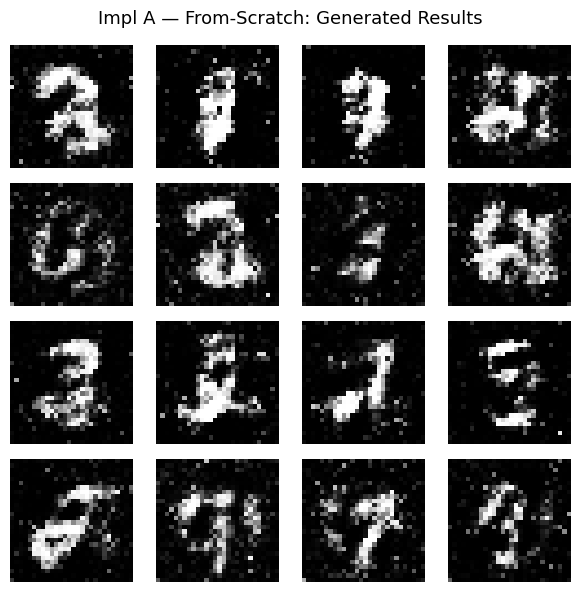

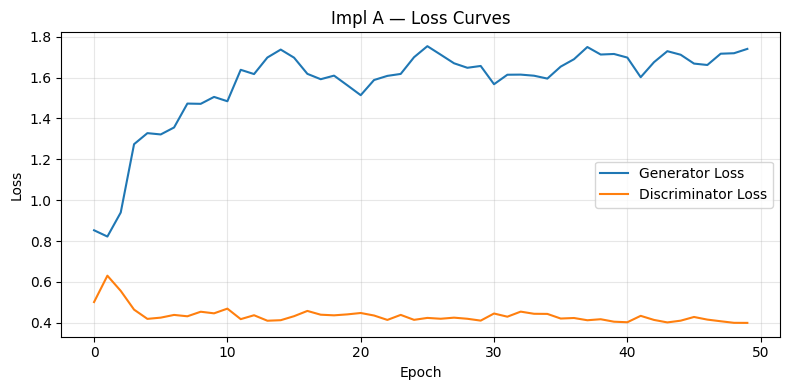

In [15]:
show_generated(gen_a, LATENT_DIM, n=16, title='Impl A — From-Scratch: Generated Results')
plot_losses(g_losses_a, d_losses_a, title='Impl A — Loss Curves')

---

## 4. 实现 B — 简洁实现

使用 `nn.Sequential` 将多层操作打包，减少样板代码。

| 源代码实现 | 简洁实现 |
|---|---|
| `GeneratorScratch` (手写 fc1/fc2/fc3 + forward) | `GeneratorConcise` (`nn.Sequential` 一行定义) |
| `DiscriminatorScratch` (手写 fc1/fc2/fc3 + forward) | `DiscriminatorConcise` (`nn.Sequential` 一行定义) |

In [16]:
class GeneratorConcise(nn.Module):
    """简洁实现：nn.Sequential 构建生成器"""
    def __init__(self, latent_dim, hidden_dim, img_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),      # 64 -> 256
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim * 2),  # 256 -> 512
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim * 2, img_dim),     # 512 -> 784
            nn.Tanh(),
        )

    def forward(self, z):
        return self.net(z)  # (batch, latent_dim) -> (batch, img_dim)


class DiscriminatorConcise(nn.Module):
    """简洁实现：nn.Sequential 构建判别器"""
    def __init__(self, img_dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(img_dim, hidden_dim * 2),     # 784 -> 512
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim * 2, hidden_dim),  # 512 -> 256
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, 1),               # 256 -> 1
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x)  # (batch, img_dim) -> (batch, 1)

In [17]:
gen_b = GeneratorConcise(LATENT_DIM, HIDDEN_DIM, IMG_DIM).to(device)
dis_b = DiscriminatorConcise(IMG_DIM, HIDDEN_DIM).to(device)
gen_b.apply(weights_init)
dis_b.apply(weights_init)

print(f'Generator  参数量: {sum(p.numel() for p in gen_b.parameters()):,}')
print(f'Discriminator 参数量: {sum(p.numel() for p in dis_b.parameters()):,}')

g_losses_b, d_losses_b = train_gan(gen_b, dis_b, dataloader)

Generator  参数量: 550,416
Discriminator 参数量: 533,505
Epoch [ 10/50]  D Loss: 0.4516  G Loss: 1.5294
Epoch [ 20/50]  D Loss: 0.4236  G Loss: 1.5279
Epoch [ 30/50]  D Loss: 0.4194  G Loss: 1.7325
Epoch [ 40/50]  D Loss: 0.4169  G Loss: 1.6857
Epoch [ 50/50]  D Loss: 0.3857  G Loss: 1.7862


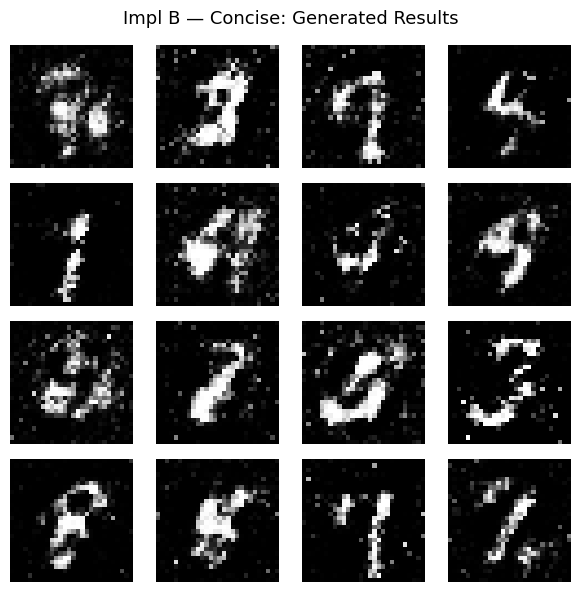

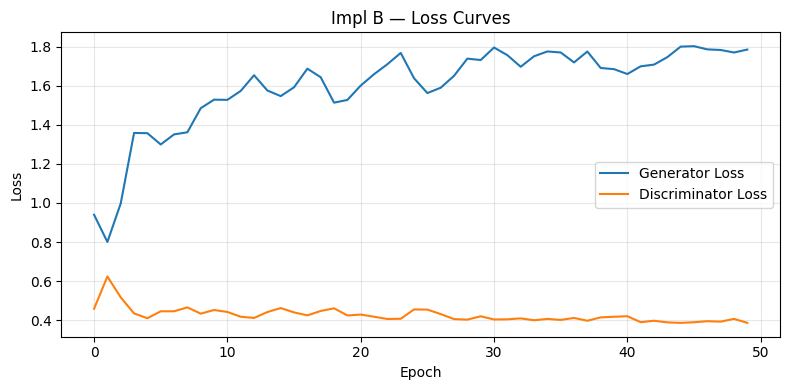

In [18]:
show_generated(gen_b, LATENT_DIM, n=16, title='Impl B — Concise: Generated Results')
plot_losses(g_losses_b, d_losses_b, title='Impl B — Loss Curves')

---

## 5. 结果对比

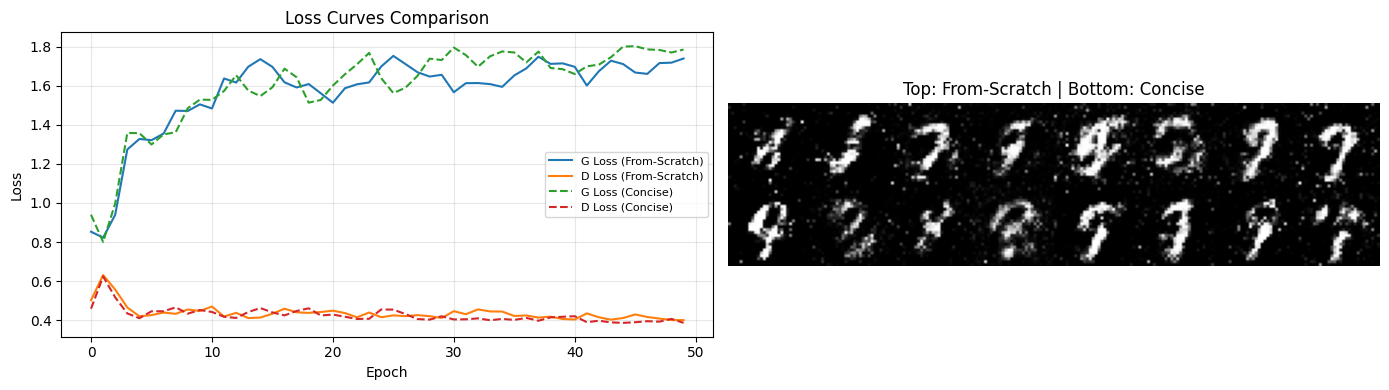

两种实现架构完全相同，结果差异仅来自随机初始化。


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── 损失曲线对比 ──
axes[0].plot(g_losses_a, label='G Loss (From-Scratch)')
axes[0].plot(d_losses_a, label='D Loss (From-Scratch)')
axes[0].plot(g_losses_b, '--', label='G Loss (Concise)')
axes[0].plot(d_losses_b, '--', label='D Loss (Concise)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curves Comparison')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# ── 生成图对比（同一组 z 输入） ──
gen_a.eval()
gen_b.eval()
z_fixed = torch.randn(8, LATENT_DIM, device=device)
with torch.no_grad():
    imgs_a = (gen_a(z_fixed).view(-1, 1, 28, 28).cpu() * 0.5 + 0.5).clamp(0, 1)
    imgs_b = (gen_b(z_fixed).view(-1, 1, 28, 28).cpu() * 0.5 + 0.5).clamp(0, 1)

row_a = np.concatenate([imgs_a[i, 0].numpy() for i in range(8)], axis=1)
row_b = np.concatenate([imgs_b[i, 0].numpy() for i in range(8)], axis=1)
grid_img = np.concatenate([row_a, row_b], axis=0)

axes[1].imshow(grid_img, cmap='gray')
axes[1].set_title('Top: From-Scratch | Bottom: Concise')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print('两种实现架构完全相同，结果差异仅来自随机初始化。')

---

## 附录 A：隐空间可视化

在隐空间中对两个随机噪声向量做线性插值 $z = (1-\alpha)z_1 + \alpha z_2$，观察生成图像的平滑过渡。

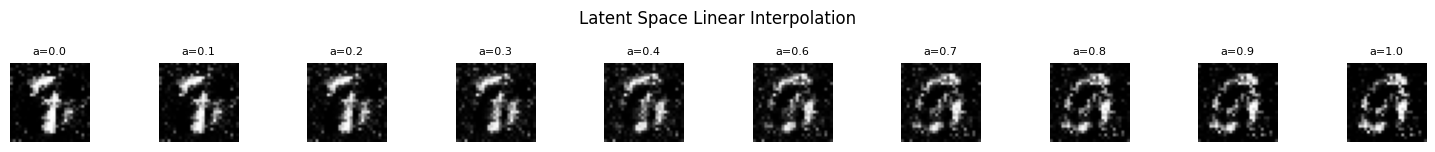

In [20]:
gen_a.eval()
with torch.no_grad():
    z1 = torch.randn(1, LATENT_DIM, device=device)
    z2 = torch.randn(1, LATENT_DIM, device=device)

    n_interp = 10
    alphas = torch.linspace(0, 1, n_interp, device=device).unsqueeze(1)  # (10, 1)
    z_interp = z1 * (1 - alphas) + z2 * alphas  # (10, latent_dim)

    imgs = (gen_a(z_interp).view(-1, 1, 28, 28).cpu() * 0.5 + 0.5).clamp(0, 1)

fig, axes = plt.subplots(1, n_interp, figsize=(15, 1.5))
for i, ax in enumerate(axes):
    ax.imshow(imgs[i, 0], cmap='gray')
    ax.set_title(f'a={alphas[i, 0]:.1f}', fontsize=8)
    ax.axis('off')
plt.suptitle('Latent Space Linear Interpolation', fontsize=12)
plt.tight_layout()
plt.show()

---

## 附录 B：面试拓展

### 高频面试题

**Q1: GAN 的核心思想是什么？**

GAN 通过两个网络的**对抗博弈**隐式学习数据分布：
- 生成器 G 将噪声映射为样本，试图欺骗判别器
- 判别器 D 学习区分真假样本
- 训练目标是极小极大博弈 $\min_G \max_D V(D,G)$
- 理想均衡状态：$p_g = p_{\text{data}}$，$D(x) = 0.5$

**Q2: 为什么 GAN 训练会出现梯度消失？**

- 训练初期，G 生成质量极差，D 轻松区分真假，$D(G(z)) \to 0$
- 原始损失 $\log(1 - D(G(z)))$ 在 $D(G(z)) \to 0$ 时梯度趋近 0，G 无法更新
- **解决方案**：使用非饱和损失 $-\log D(G(z))$，在训练初期提供更大梯度

**Q3: 什么是模式坍塌（Mode Collapse）？如何解决？**

- G 学会生成少数几种样本就能骗过 D，丧失多样性
- 本质原因：G 对特定 D 过拟合，在 D 更新后 G 转向下一个模式，循环往复
- 解决方案：
  - WGAN：用 Wasserstein 距离替代 JS 散度
  - Mini-batch discrimination：D 同时考虑一批样本的多样性
  - Unrolled GAN：G 更新时考虑 D 未来的变化

**Q4: WGAN 做了什么改进？Wasserstein 距离有何优势？**

- 原始 GAN 等价于最小化 JS 散度，当两分布不重叠时 JS 为常数（梯度为 0）
- WGAN 使用 Wasserstein 距离（Earth Mover's Distance），即使分布不重叠也能提供有意义的梯度
- 实现要点：移除 D 最后的 Sigmoid，权重裁剪（weight clipping）保证 Lipschitz 连续性
- WGAN-GP 进一步用梯度惩罚（gradient penalty）替代权重裁剪，训练更稳定

**Q5: 为什么判别器使用 LeakyReLU 而不是 ReLU？**

- ReLU 对负值输出 0，可能导致大量神经元永久死亡（dead neurons），尤其在判别器中
- LeakyReLU 对负值保留一个小斜率（如 0.2），保持梯度流动
- 这对 GAN 训练尤为重要：判别器需要稳定的梯度信号来指导生成器学习

**Q6: GAN 的优化目标与 JS 散度有什么关系？**

- 给定最优判别器 $D^*(x) = \frac{p_{\text{data}}(x)}{p_{\text{data}}(x) + p_g(x)}$
- 将 $D^*$ 代入价值函数可证明：$\max_D V(D,G) = 2 \cdot JSD(p_{\text{data}} \| p_g) - \log 4$
- 因此训练 G 等价于最小化 $p_g$ 与 $p_{\text{data}}$ 之间的 Jensen-Shannon 散度

**Q7: GAN 的评价指标有哪些？FID 和 IS 的区别？**

| 指标 | 含义 | 优缺点 |
|------|------|--------|
| IS (Inception Score) | 用预训练 Inception 网络评估生成图像的类别清晰度和多样性 | 不直接比较真实分布，可能被对抗样本欺骗 |
| FID (Fréchet Inception Distance) | 计算真实图像和生成图像在 Inception 特征空间中的分布距离 | 更鲁棒，直接度量分布差异；是当前主流指标 |

**Q8: GAN vs VAE vs Diffusion Model？**

| 对比维度 | GAN | VAE | Diffusion Model |
|---------|-----|-----|----------------|
| 核心思想 | 对抗博弈 | 变分推断 + 重参数化 | 逐步去噪 |
| 生成质量 | 高（锐利） | 中（偏模糊） | 最高 |
| 训练稳定性 | 差（模式坍塌） | 好 | 好 |
| 生成速度 | 快（单次前向） | 快 | 慢（多步迭代） |
| 显式分布 | 无 | 有（ELBO） | 有 |
| 多样性 | 易缺失 | 好 | 最好 |

### 进阶探索方向

- **DCGAN**: 用卷积替代全连接，利用转置卷积实现图像生成，引入 BatchNorm 稳定训练
- **条件 GAN (cGAN)**: 向 G 和 D 注入条件信息（类别标签），实现可控生成
- **StyleGAN**: 引入样式注入和渐进式训练，生成高分辨率逼真人脸
- **CycleGAN**: 无配对数据的跨域图像转换，核心是循环一致性损失